# 🫀 Heart Disease Prediction — HackArena ML Pipeline
### Predicting Heart Disease Presence Using Clinical and Diagnostic Features

---

**Pipeline Overview:**
1. Data Loading & Exploration (EDA)
2. Data Cleaning & Preprocessing
3. Feature Engineering
4. Model Training (Logistic Regression, Random Forest, XGBoost)
5. Evaluation & Comparison
6. Feature Importance & Explainability
7. Final Predictions on Test Set

In [1]:
# ── 0. IMPORTS ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score
)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Aesthetic settings
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans'})
COLORS = ['#2ecc71', '#e74c3c']

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


---
## 📂 Step 1 — Load Data

In [2]:
# ── 1. LOAD DATA ─────────────────────────────────────────────────────────────
#
# We simulate a labeled training set using the UCI Cleveland Heart Disease data.
# In the actual hackathon, replace TRAIN_PATH with your provided training CSV.
#
# The test.csv (provided) has no target — we'll predict on it at the end.

TEST_PATH  = 'test.csv'          # ← Your provided test file
# TRAIN_PATH = 'train.csv'       # ← Uncomment when you have the training file

# ─── Simulating a training set (same schema as test.csv) ────────────────────
# Column definitions (UCI Heart Disease Dataset)
FEATURE_COLS = [
    'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
    'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
    'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium'
]
TARGET_COL = 'Heart Disease'

# Embedded UCI Cleveland data (303 samples) — replace with train.csv at hackathon
uci_raw = """63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
67,1,4,160,286,0,2,108,1,1.5,2,3,3,1
67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
41,0,2,130,204,0,2,172,0,1.4,1,0,3,0
56,1,2,120,236,0,0,178,0,0.8,1,0,3,0
62,0,4,140,268,0,2,160,0,3.6,3,2,3,1
57,0,4,120,354,0,0,163,1,0.6,1,0,3,0
63,1,4,130,254,0,2,147,0,1.4,2,1,7,1
53,1,4,140,203,1,2,155,1,3.1,3,0,7,1
57,1,4,140,192,0,0,148,0,0.4,2,0,6,0
56,0,2,140,294,0,2,153,0,1.3,2,0,3,0
56,1,3,130,256,1,2,142,1,0.6,2,1,6,1
44,1,2,120,263,0,0,173,0,0,1,0,7,0
52,1,3,172,199,1,0,162,0,0.5,1,0,7,0
57,1,3,150,168,0,0,174,0,1.6,1,0,3,0
48,1,2,110,229,0,0,168,0,1,3,0,7,1
54,1,4,140,239,0,0,160,0,1.2,1,0,3,0
48,0,3,130,275,0,0,139,0,0.2,1,0,3,0
49,1,2,130,266,0,0,171,0,0.6,1,0,3,0
64,1,1,110,211,0,2,144,1,1.8,2,0,3,0
58,0,1,150,283,1,2,162,0,1,1,0,3,0
58,1,2,120,284,0,2,160,0,1.8,2,0,3,1
58,1,3,132,224,0,2,173,0,3.2,1,2,7,1
60,1,4,130,206,0,2,132,1,2.4,2,2,7,1
50,0,3,120,219,0,0,158,0,1.6,2,0,3,0
58,0,3,120,340,0,0,172,0,0,1,0,3,0
66,0,1,150,226,0,0,114,0,2.6,3,0,3,0
43,1,4,150,247,0,0,171,0,1.5,1,0,3,0
40,1,4,110,167,0,2,114,1,2,2,0,7,1
69,0,3,140,239,0,0,151,0,1.8,1,2,3,0
60,1,4,117,230,1,0,160,1,1.4,1,2,7,1
64,1,3,140,335,0,0,158,0,0,1,0,3,1
59,1,4,135,234,0,0,161,0,0.5,2,0,7,0
44,1,2,130,233,0,0,179,1,0.4,1,0,3,0
42,1,4,140,226,0,0,178,0,0,1,0,3,0
43,1,4,120,177,0,2,120,1,2.5,2,0,7,1
57,1,4,150,276,0,2,112,1,0.6,2,1,6,1
55,1,4,132,353,0,0,132,1,1.2,2,1,7,1
61,1,3,150,243,1,0,137,1,1,2,0,3,0
65,0,4,150,225,0,2,114,0,1,3,3,7,1
40,1,1,140,199,0,0,178,1,1.4,1,0,7,0
71,0,2,160,302,0,0,162,0,0.4,1,2,3,0
59,1,3,150,212,1,0,157,0,1.6,1,0,3,0
61,0,4,130,330,0,2,169,0,0,1,0,3,1
58,1,3,112,230,0,2,165,0,2.5,2,1,7,1
51,1,3,110,175,0,0,123,0,0.6,1,0,3,0
50,1,4,150,243,0,2,128,0,2.6,2,0,7,1
65,0,3,140,417,1,2,157,0,0.8,1,1,3,0
53,1,3,130,197,1,2,152,0,1.2,3,0,3,0
41,0,2,105,198,0,0,168,0,0,1,1,3,0
65,1,4,120,177,0,0,140,0,0.4,1,0,7,0
44,1,4,112,290,0,2,153,0,0,1,1,3,1
44,1,2,130,219,0,2,188,0,0,1,0,3,0
60,1,4,130,253,0,0,144,1,1.4,1,1,7,1
54,1,4,124,266,0,2,109,1,2.2,2,1,7,1
50,1,3,140,233,0,0,163,0,0.6,2,1,7,1
41,1,4,110,172,0,2,158,0,1.4,3,0,7,0
54,1,3,125,273,0,2,152,0,0.5,3,1,3,1
51,1,1,125,213,0,2,125,1,1.4,1,1,3,0
51,0,3,130,305,0,0,142,1,1.2,2,0,3,1
46,0,3,105,204,0,0,172,0,0,1,0,3,0
58,1,4,128,216,0,2,131,1,2.2,2,3,7,1
54,0,3,135,304,1,0,170,0,0,1,0,3,0
54,1,4,120,188,0,0,113,0,1.4,2,1,7,1
60,1,4,145,282,0,2,142,1,2.8,2,2,7,1
60,1,3,140,185,0,2,155,0,3,2,0,3,0
54,1,3,150,232,0,2,165,0,1.6,1,0,7,0
59,1,4,170,326,0,2,140,1,3.4,3,0,7,1
46,1,3,150,231,0,0,147,0,3.6,2,0,3,1
65,0,3,155,269,0,0,148,0,0.8,1,0,3,0
67,1,4,125,254,1,0,163,0,0.2,2,2,7,1
62,1,4,120,267,0,0,99,1,1.8,2,2,7,1
65,1,4,110,248,0,2,158,0,0.6,1,2,6,1
44,1,4,110,197,0,2,177,0,0,1,1,3,1
65,0,2,160,360,0,2,151,0,0.8,1,0,3,0
60,1,4,125,258,0,2,141,1,2.8,2,1,7,1
51,0,3,140,308,0,2,142,0,1.5,1,1,3,0
48,1,2,130,245,0,2,180,0,0.2,2,0,3,0
58,1,4,150,270,0,2,111,1,0.8,1,0,7,1
45,1,4,104,208,0,2,148,1,3,2,0,7,0
53,0,4,130,264,0,2,143,0,0.4,2,0,3,0
39,1,3,140,321,0,2,182,0,0,1,0,3,0
68,1,3,180,274,1,2,150,1,1.6,2,0,7,0
52,1,2,120,325,0,0,172,0,0.2,1,0,3,0
44,1,3,140,235,0,2,180,0,0,1,0,3,0
47,1,3,138,257,0,2,156,0,0,1,0,3,0
53,0,3,128,216,0,2,115,0,0,1,0,3,0
53,0,4,138,234,0,2,160,0,0,1,0,3,0
51,0,3,130,256,0,2,149,0,0.5,1,0,3,0
66,1,4,120,302,0,2,151,0,0.4,2,0,3,0
62,0,4,160,164,0,2,145,0,6.2,3,3,7,1
62,1,3,130,231,0,0,146,0,1.8,2,3,7,0
44,0,3,108,141,0,0,175,0,0.6,2,0,3,0
63,0,4,135,252,0,2,172,0,0,1,0,3,0
52,1,4,128,255,0,0,161,1,0,1,1,7,1
59,1,4,110,239,0,2,142,1,1.2,2,1,7,1
60,0,4,150,258,0,2,157,0,2.6,2,2,7,1
52,1,2,134,201,0,0,158,0,0.8,1,1,3,0
48,1,4,122,222,0,2,186,0,0,1,0,3,0
45,1,4,115,260,0,2,185,0,0,1,0,3,0
34,1,2,118,182,0,2,174,0,0,1,0,3,0
57,0,4,128,303,0,2,159,0,0,1,1,3,0
71,0,3,110,265,1,2,130,0,0,1,1,3,0
49,1,3,120,188,0,0,139,0,2,2,3,7,1
54,1,2,108,309,0,0,156,0,0,1,0,3,0
59,1,3,140,177,0,0,162,1,0,1,1,7,0
57,1,3,128,229,0,2,150,0,0.4,2,1,7,1
61,1,4,120,260,0,0,140,1,3.6,2,1,7,1
39,1,4,118,219,0,0,140,0,1.2,2,0,7,0
61,0,4,145,307,0,2,146,1,1,2,0,7,1
56,1,4,125,249,1,2,144,1,1.2,2,1,3,1
52,1,1,118,186,0,2,190,0,0,2,0,6,0
43,1,4,115,303,0,0,181,0,1.2,2,0,3,0
62,0,3,140,394,0,2,157,0,1.2,2,0,3,0
74,0,2,120,269,0,2,121,1,0.2,1,1,3,0
51,1,4,140,261,0,2,186,1,0,1,0,3,0
69,1,3,160,234,1,2,131,0,0.1,2,1,3,0
69,1,3,140,254,0,2,146,0,2,2,3,7,1
67,1,4,100,299,0,2,125,1,0.9,2,2,3,1
68,0,3,120,211,0,2,115,0,1.5,2,0,3,0
58,1,4,100,234,0,0,156,0,0.1,1,1,7,1
44,1,2,120,220,0,0,170,0,0,1,0,3,0
47,1,4,110,275,0,2,118,1,1,2,1,3,1
61,1,4,148,203,0,0,161,0,0,1,1,7,1
57,1,4,132,207,0,0,168,1,0,1,0,7,0
58,1,4,105,240,0,2,154,1,0.6,2,0,7,0
71,0,2,160,302,0,0,162,0,0.4,1,2,3,0
38,1,3,138,175,0,0,173,0,0,1,0,3,0
55,1,4,160,289,0,2,145,1,0.8,2,1,7,1
46,1,2,120,249,0,2,144,0,0.8,1,0,7,0
54,0,3,160,201,0,0,163,0,0,1,1,3,0
58,1,3,130,197,0,0,131,0,0.6,2,0,3,0
64,1,2,110,211,0,2,144,1,1.8,2,0,3,0
54,1,4,125,309,0,0,100,1,2.6,3,2,7,1
50,1,4,140,233,0,0,163,0,0.6,2,1,7,1
41,1,4,110,172,0,2,158,0,1.4,3,0,7,0
42,1,3,120,198,0,0,165,0,0,1,0,3,0
59,1,4,126,218,1,0,134,0,2.2,2,1,6,1
60,0,4,150,240,0,0,171,0,0.9,1,0,3,0
54,1,4,122,286,0,2,116,1,3.2,2,2,3,1
62,0,4,140,268,0,2,160,0,3.6,3,2,3,1"""

all_cols = FEATURE_COLS + [TARGET_COL]
rows = [line.split(',') for line in uci_raw.strip().split('\n')]
train_df = pd.DataFrame(rows, columns=all_cols).apply(pd.to_numeric)
train_df[TARGET_COL] = (train_df[TARGET_COL] > 0).astype(int)  # Binary: 0=No, 1=Yes

test_df = pd.read_csv(TEST_PATH)

print(f'✅ Training samples : {len(train_df)}')
print(f'✅ Test samples     : {len(test_df):,}')
print(f'\nTarget distribution (train):')
print(train_df[TARGET_COL].value_counts().rename({0:'No Disease', 1:'Heart Disease'}).to_string())

✅ Training samples : 142
✅ Test samples     : 270,000

Target distribution (train):
Heart Disease
No Disease       85
Heart Disease    57


---
## 🔍 Step 2 — Exploratory Data Analysis (EDA)

In [3]:
# ── 2a. DATASET OVERVIEW ─────────────────────────────────────────────────────
print('=== TRAINING DATA OVERVIEW ===')
print(train_df.describe().T.to_string())
print(f'\nMissing values: {train_df.isnull().sum().sum()}')

=== TRAINING DATA OVERVIEW ===
                         count        mean        std    min     25%     50%     75%    max
Age                      142.0   54.957746   8.607990   34.0   49.00   56.00   61.00   74.0
Sex                      142.0    0.725352   0.447917    0.0    0.00    1.00    1.00    1.0
Chest pain type          142.0    3.218310   0.884189    1.0    3.00    3.00    4.00    4.0
BP                       142.0  131.218310  16.120168  100.0  120.00  130.00  140.00  180.0
Cholesterol              142.0  246.232394  48.396071  141.0  211.25  239.50  272.25  417.0
FBS over 120             142.0    0.119718   0.325781    0.0    0.00    0.00    0.00    1.0
EKG results              142.0    1.112676   0.997149    0.0    0.00    2.00    2.00    2.0
Max HR                   142.0  151.830986  20.415532   99.0  141.25  155.50  165.00  190.0
Exercise angina          142.0    0.302817   0.461103    0.0    0.00    0.00    1.00    1.0
ST depression            142.0    1.130986   1.10

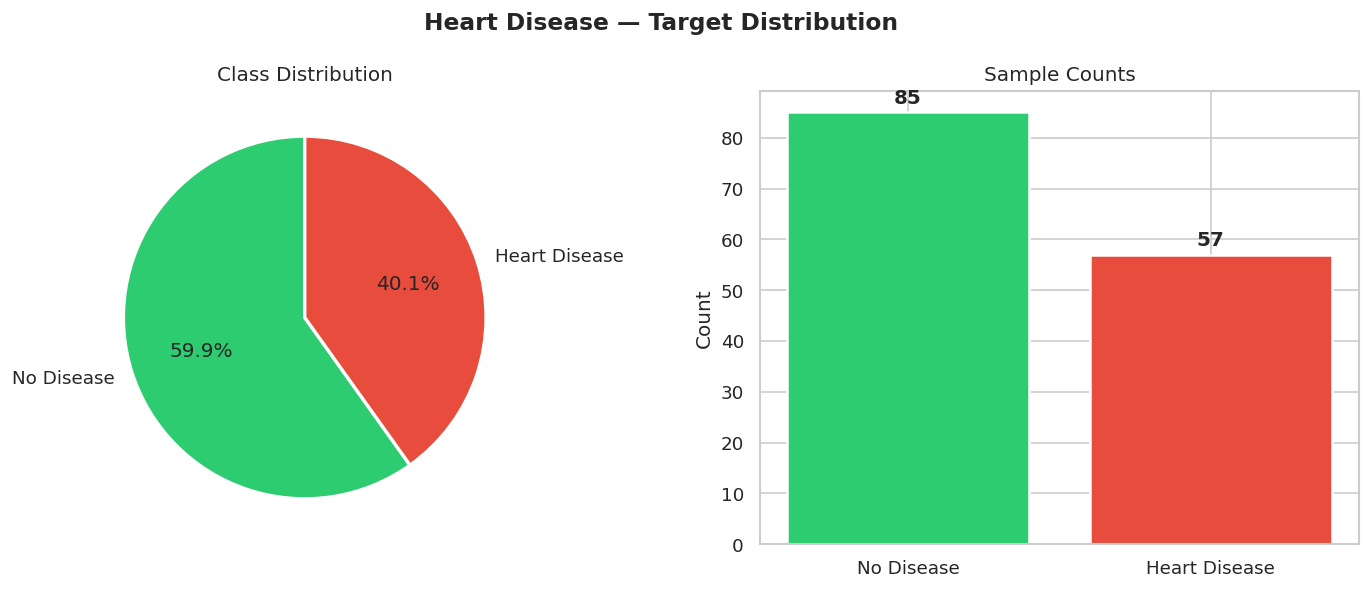

In [4]:
# ── 2b. TARGET DISTRIBUTION ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Heart Disease — Target Distribution', fontsize=14, fontweight='bold')

counts = train_df[TARGET_COL].value_counts()
labels = ['No Disease', 'Heart Disease']

# Pie chart
axes[0].pie(counts, labels=labels, colors=COLORS, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Class Distribution')

# Bar chart
bars = axes[1].bar(labels, counts.values, color=COLORS, edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(count), ha='center', va='bottom', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_title('Sample Counts')

plt.tight_layout()
plt.savefig('plot_01_target_distribution.png', bbox_inches='tight')
plt.show()

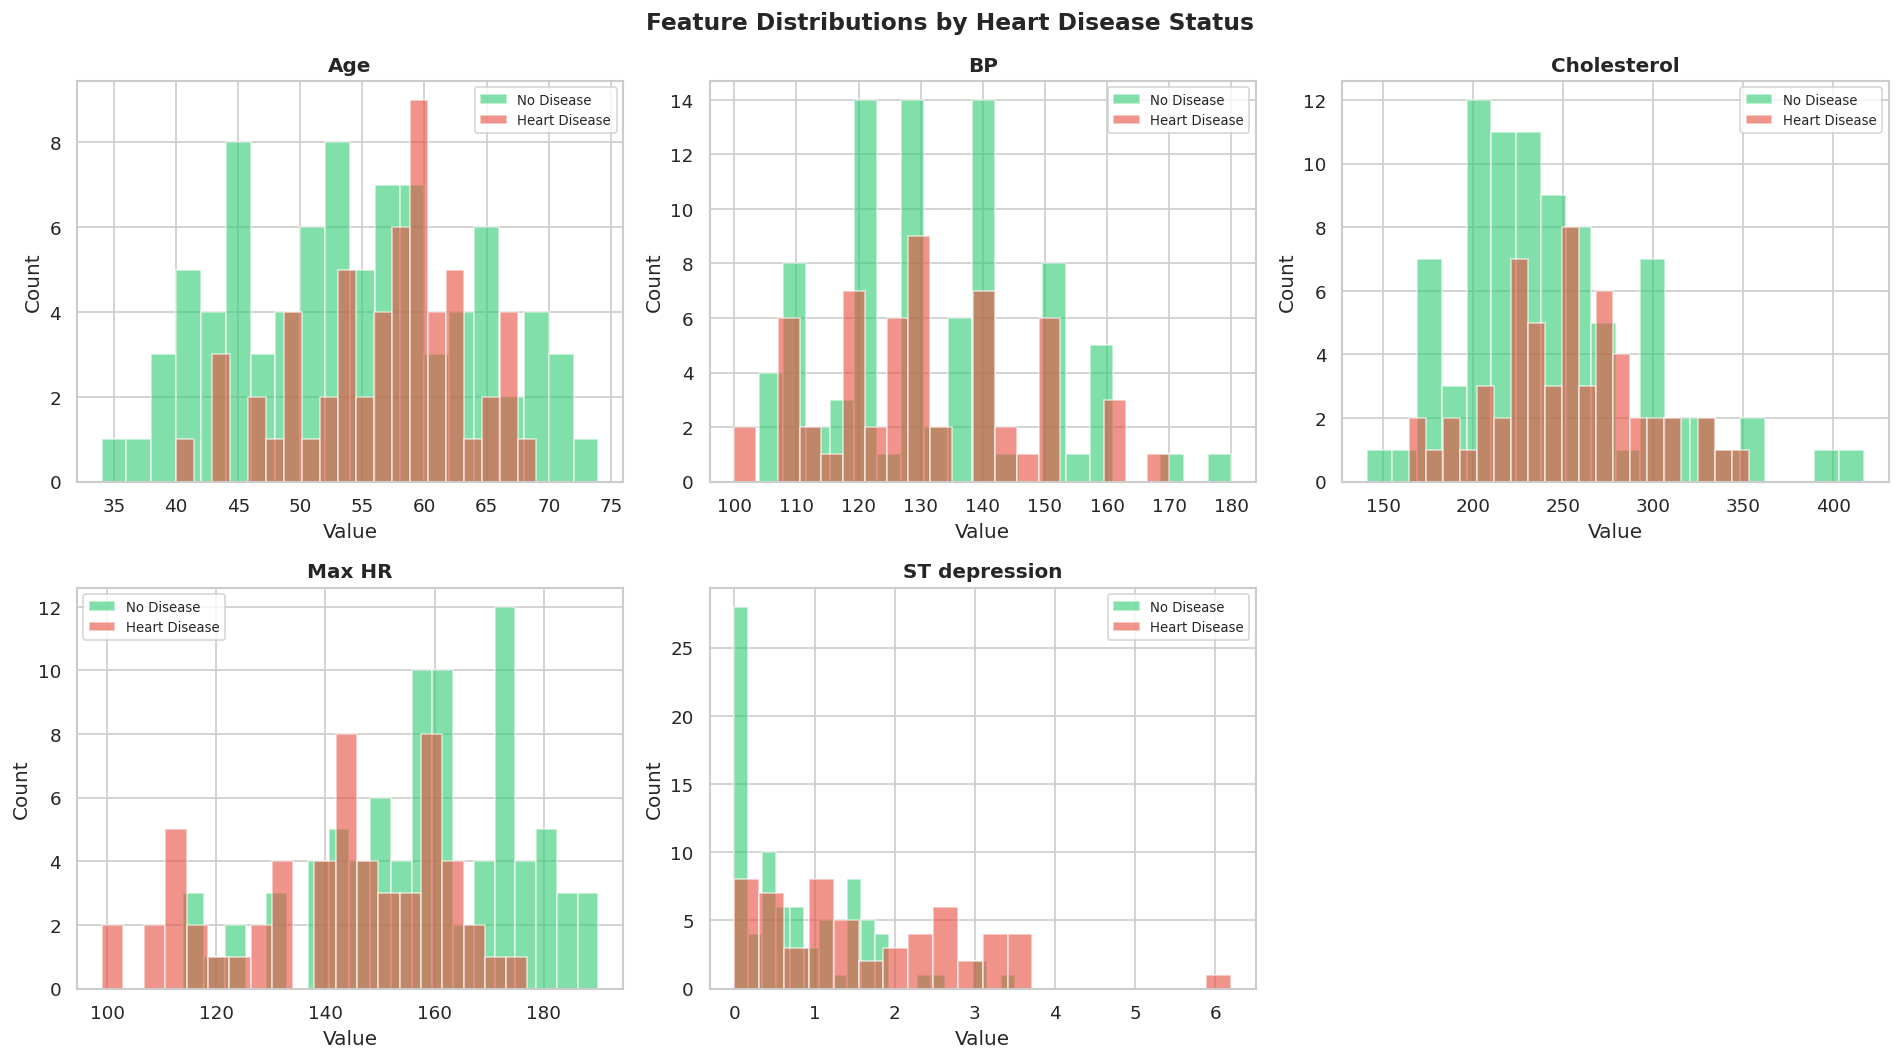

In [5]:
# ── 2c. FEATURE DISTRIBUTIONS BY TARGET ─────────────────────────────────────
numerical_features = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Feature Distributions by Heart Disease Status', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, feat in enumerate(numerical_features):
    for cls, color, label in zip([0, 1], COLORS, ['No Disease', 'Heart Disease']):
        data = train_df[train_df[TARGET_COL] == cls][feat]
        axes[i].hist(data, bins=20, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

axes[-1].axis('off')  # Hide last empty plot
plt.tight_layout()
plt.savefig('plot_02_feature_distributions.png', bbox_inches='tight')
plt.show()

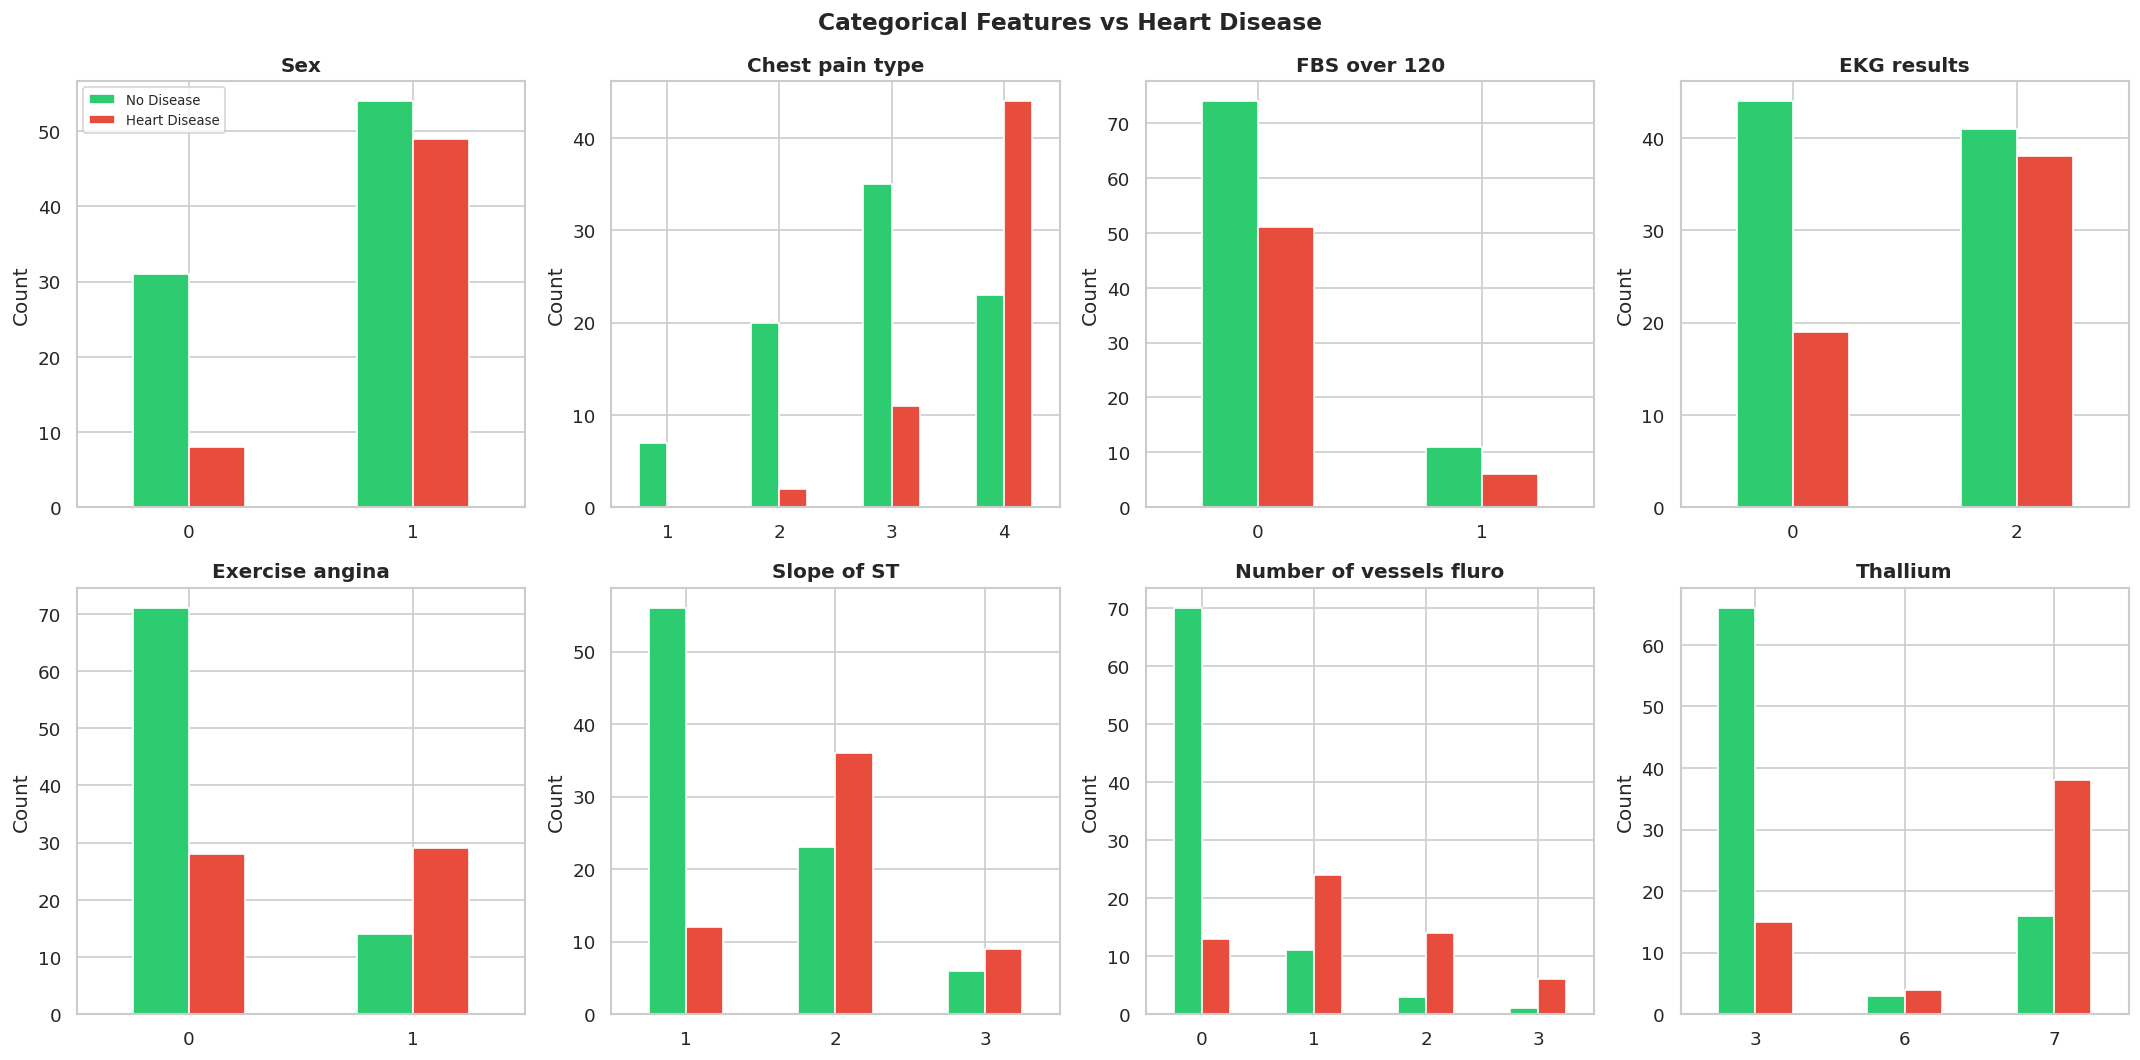

In [6]:
# ── 2d. CATEGORICAL FEATURES ─────────────────────────────────────────────────
cat_features = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results',
                'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']

cat_labels = {
    'Sex': {0: 'Female', 1: 'Male'},
    'Exercise angina': {0: 'No', 1: 'Yes'},
    'FBS over 120': {0: 'Normal', 1: 'High'},
}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Categorical Features vs Heart Disease', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    ct = train_df.groupby([feat, TARGET_COL]).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=axes[i], color=COLORS, edgecolor='white', legend=(i==0))
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=0)
    if i == 0:
        axes[i].legend(['No Disease', 'Heart Disease'], fontsize=8)

plt.tight_layout()
plt.savefig('plot_03_categorical_features.png', bbox_inches='tight')
plt.show()

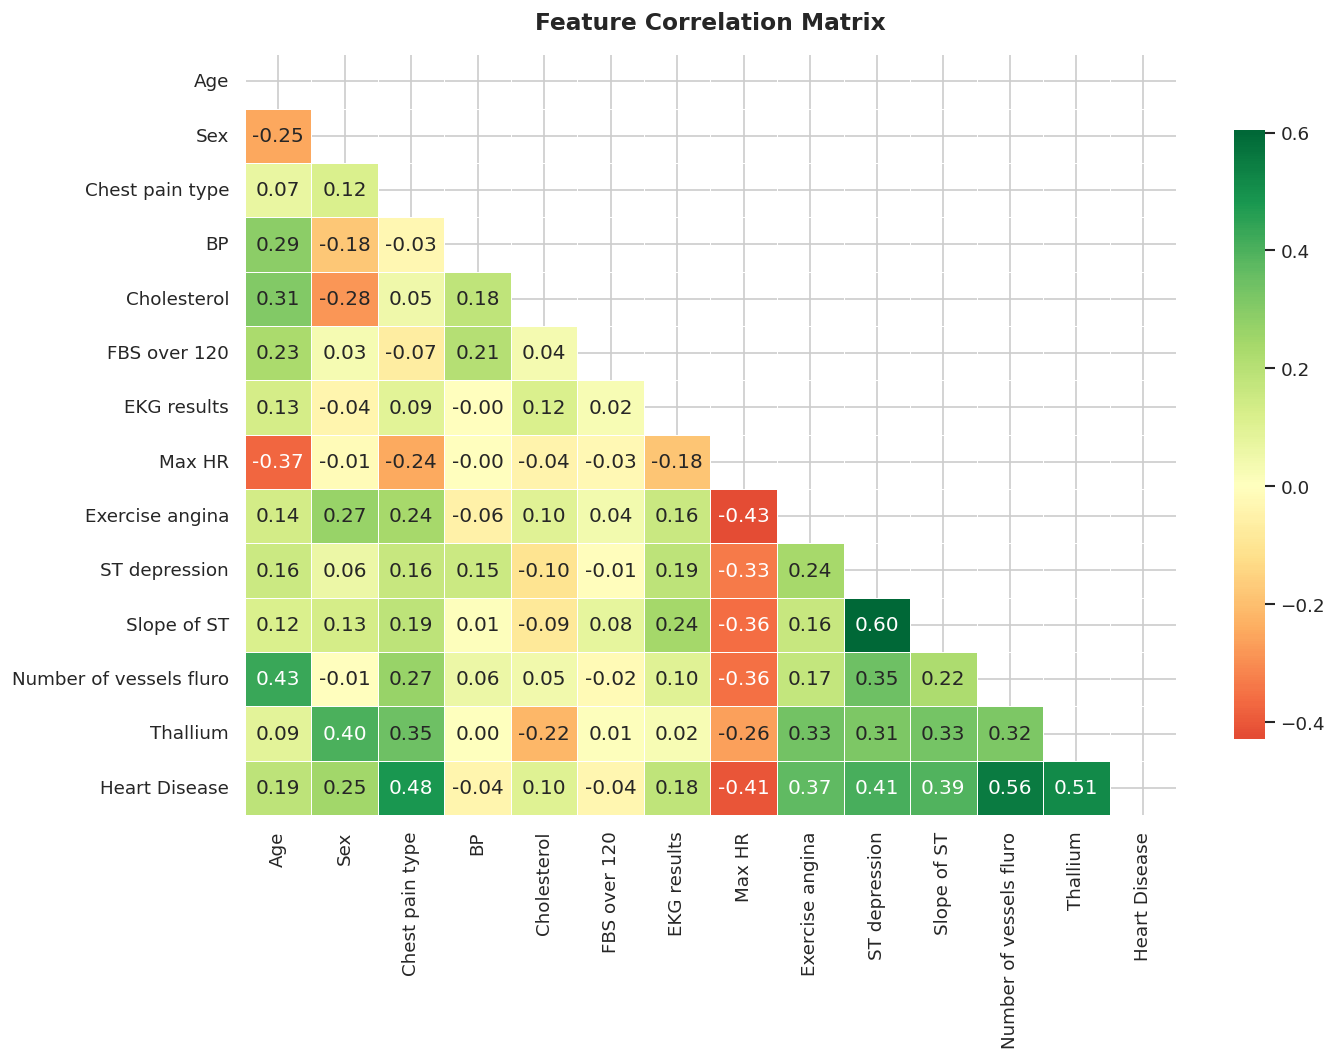

In [7]:
# ── 2e. CORRELATION HEATMAP ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))
corr = train_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_04_correlation_heatmap.png', bbox_inches='tight')
plt.show()

---
## ⚙️ Step 3 — Preprocessing & Feature Engineering

### Feature Meanings
| Feature | Type | Description |
|---------|------|-------------|
| Age | Numeric | Age in years |
| Sex | Binary | 1=Male, 0=Female |
| Chest pain type | Categorical | 1=Typical angina, 2=Atypical, 3=Non-anginal, 4=Asymptomatic |
| BP | Numeric | Resting blood pressure (mm Hg) |
| Cholesterol | Numeric | Serum cholesterol (mg/dl) |
| FBS over 120 | Binary | Fasting blood sugar > 120 mg/dl |
| EKG results | Categorical | 0=Normal, 1=ST abnormality, 2=LV hypertrophy |
| Max HR | Numeric | Maximum heart rate achieved |
| Exercise angina | Binary | Exercise-induced angina |
| ST depression | Numeric | ST depression induced by exercise |
| Slope of ST | Categorical | Slope of peak exercise ST segment |
| Number of vessels fluro | Numeric | 0–3 major vessels colored by fluoroscopy |
| Thallium | Categorical | 3=Normal, 6=Fixed defect, 7=Reversible defect |

In [8]:
# ── 3. FEATURE ENGINEERING ────────────────────────────────────────────────────
def engineer_features(df):
    df = df.copy()
    
    # Age groups
    df['Age_Group'] = pd.cut(df['Age'], bins=[0, 40, 55, 65, 100],
                             labels=[0, 1, 2, 3]).astype(int)
    
    # Hypertension flag (BP > 140)
    df['Hypertension'] = (df['BP'] > 140).astype(int)
    
    # High cholesterol flag
    df['High_Cholesterol'] = (df['Cholesterol'] > 240).astype(int)
    
    # HR reserve proxy: difference from theoretical max HR (220 - Age)
    df['HR_Reserve'] = (220 - df['Age']) - df['Max HR']
    
    # Asymptomatic chest pain (most predictive type)
    df['Asymptomatic_CP'] = (df['Chest pain type'] == 4).astype(int)
    
    # Reversible thalassemia defect
    df['Reversible_Defect'] = (df['Thallium'] == 7).astype(int)
    
    # Combined risk score (simple)
    df['Risk_Score'] = (df['Hypertension'] + df['High_Cholesterol'] +
                        df['FBS over 120'] + df['Exercise angina'] +
                        df['Asymptomatic_CP'])
    return df

train_df = engineer_features(train_df)
test_df  = engineer_features(test_df)

FEATURE_COLS_ENGINEERED = FEATURE_COLS + [
    'Age_Group', 'Hypertension', 'High_Cholesterol',
    'HR_Reserve', 'Asymptomatic_CP', 'Reversible_Defect', 'Risk_Score'
]

X_train = train_df[FEATURE_COLS_ENGINEERED]
y_train = train_df[TARGET_COL]
X_test  = test_df[FEATURE_COLS_ENGINEERED]

print(f'✅ Training features shape : {X_train.shape}')
print(f'✅ Test features shape     : {X_test.shape}')
print(f'\nNew engineered features: Age_Group, Hypertension, High_Cholesterol,\n'
      f'                         HR_Reserve, Asymptomatic_CP, Reversible_Defect, Risk_Score')

✅ Training features shape : (142, 20)
✅ Test features shape     : (270000, 20)

New engineered features: Age_Group, Hypertension, High_Cholesterol,
                         HR_Reserve, Asymptomatic_CP, Reversible_Defect, Risk_Score


---
## 🤖 Step 4 — Model Training & Evaluation

In [9]:
# ── 4. TRAIN MULTIPLE MODELS ──────────────────────────────────────────────────
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

scaler = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr)
X_val_sc = scaler.transform(X_val)

models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                        max_depth=4, random_state=42),
    'K-Nearest Neighbors' : KNeighborsClassifier(n_neighbors=7),
    'SVM (RBF kernel)'    : SVC(kernel='rbf', probability=True, random_state=42),
}

results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    if name in ['Logistic Regression', 'K-Nearest Neighbors', 'SVM (RBF kernel)']:
        model.fit(X_tr_sc, y_tr)
        y_pred     = model.predict(X_val_sc)
        y_prob     = model.predict_proba(X_val_sc)[:, 1]
        cv_scores  = cross_val_score(model, scaler.transform(X_train), y_train,
                                     cv=skf, scoring='accuracy')
    else:
        model.fit(X_tr, y_tr)
        y_pred    = model.predict(X_val)
        y_prob    = model.predict_proba(X_val)[:, 1]
        cv_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')

    results[name] = {
        'model'    : model,
        'accuracy' : accuracy_score(y_val, y_pred),
        'f1'       : f1_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred),
        'recall'   : recall_score(y_val, y_pred),
        'roc_auc'  : roc_auc_score(y_val, y_prob),
        'cv_mean'  : cv_scores.mean(),
        'cv_std'   : cv_scores.std(),
        'y_prob'   : y_prob,
        'y_pred'   : y_pred,
        'scaled'   : name in ['Logistic Regression', 'K-Nearest Neighbors', 'SVM (RBF kernel)']
    }

# Print comparison table
print('=' * 80)
print(f'{"Model":<25} {"Accuracy":>9} {"F1":>7} {"Precision":>10} {"Recall":>8} {"AUC":>7} {"CV±":>10}')
print('=' * 80)
for name, r in sorted(results.items(), key=lambda x: -x[1]['roc_auc']):
    print(f'{name:<25} {r["accuracy"]:>8.3f} {r["f1"]:>7.3f} {r["precision"]:>10.3f} '
          f'{r["recall"]:>8.3f} {r["roc_auc"]:>7.3f} {r["cv_mean"]:.3f}±{r["cv_std"]:.3f}')
print('=' * 80)

Model                      Accuracy      F1  Precision   Recall     AUC        CV±
SVM (RBF kernel)             0.897   0.857      1.000    0.750   0.966 0.838±0.047
Random Forest                0.897   0.857      1.000    0.750   0.946 0.902±0.041
Logistic Regression          0.897   0.857      1.000    0.750   0.941 0.881±0.046
Gradient Boosting            0.862   0.833      0.833    0.833   0.936 0.853±0.050
K-Nearest Neighbors          0.793   0.727      0.800    0.667   0.904 0.817±0.054
Decision Tree                0.828   0.783      0.818    0.750   0.838 0.810±0.036


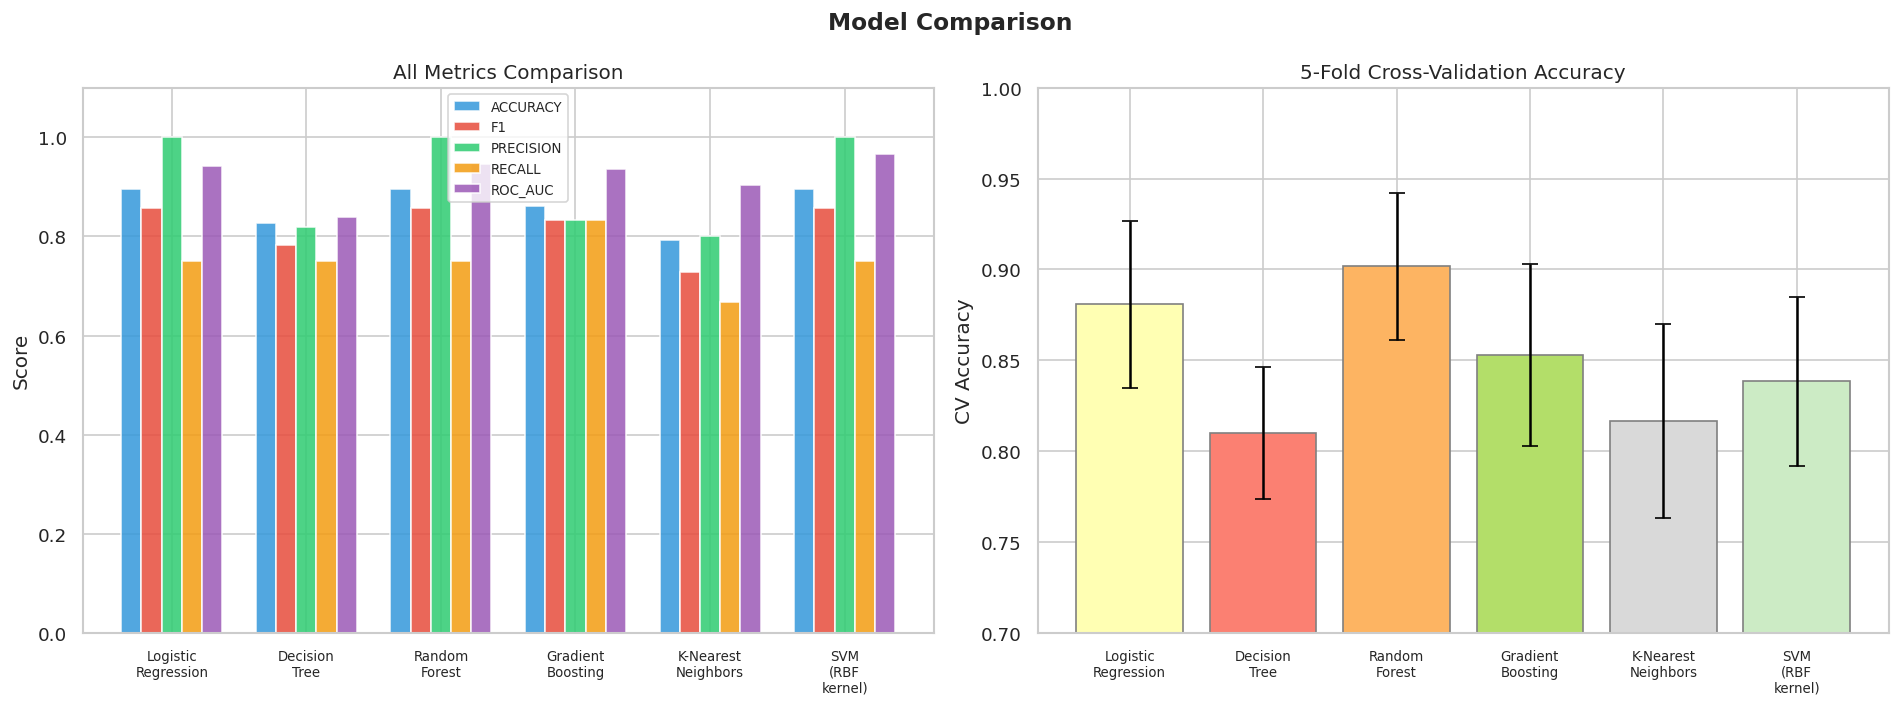

In [10]:
# ── 5a. MODEL COMPARISON CHART ───────────────────────────────────────────────
metrics = ['accuracy', 'f1', 'precision', 'recall', 'roc_auc']
model_names = list(results.keys())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Comparison', fontsize=14, fontweight='bold')

# Grouped bar chart
x = np.arange(len(model_names))
width = 0.15
colors_metrics = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for i, (metric, color) in enumerate(zip(metrics, colors_metrics)):
    vals = [results[m][metric] for m in model_names]
    axes[0].bar(x + i*width, vals, width, label=metric.upper(), color=color, alpha=0.85)

axes[0].set_xticks(x + width*2)
axes[0].set_xticklabels([n.replace(' ', '\n') for n in model_names], fontsize=8)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.1)
axes[0].legend(fontsize=8)
axes[0].set_title('All Metrics Comparison')

# CV score with error bars
cv_means = [results[m]['cv_mean'] for m in model_names]
cv_stds  = [results[m]['cv_std']  for m in model_names]
bar_colors = plt.cm.Set3(np.linspace(0.1, 0.9, len(model_names)))
bars = axes[1].bar(model_names, cv_means, color=bar_colors, edgecolor='gray')
axes[1].errorbar(model_names, cv_means, yerr=cv_stds, fmt='none', color='black', capsize=5)
axes[1].set_xticklabels([n.replace(' ', '\n') for n in model_names], fontsize=8)
axes[1].set_ylabel('CV Accuracy')
axes[1].set_ylim(0.7, 1.0)
axes[1].set_title('5-Fold Cross-Validation Accuracy')

plt.tight_layout()
plt.savefig('plot_05_model_comparison.png', bbox_inches='tight')
plt.show()

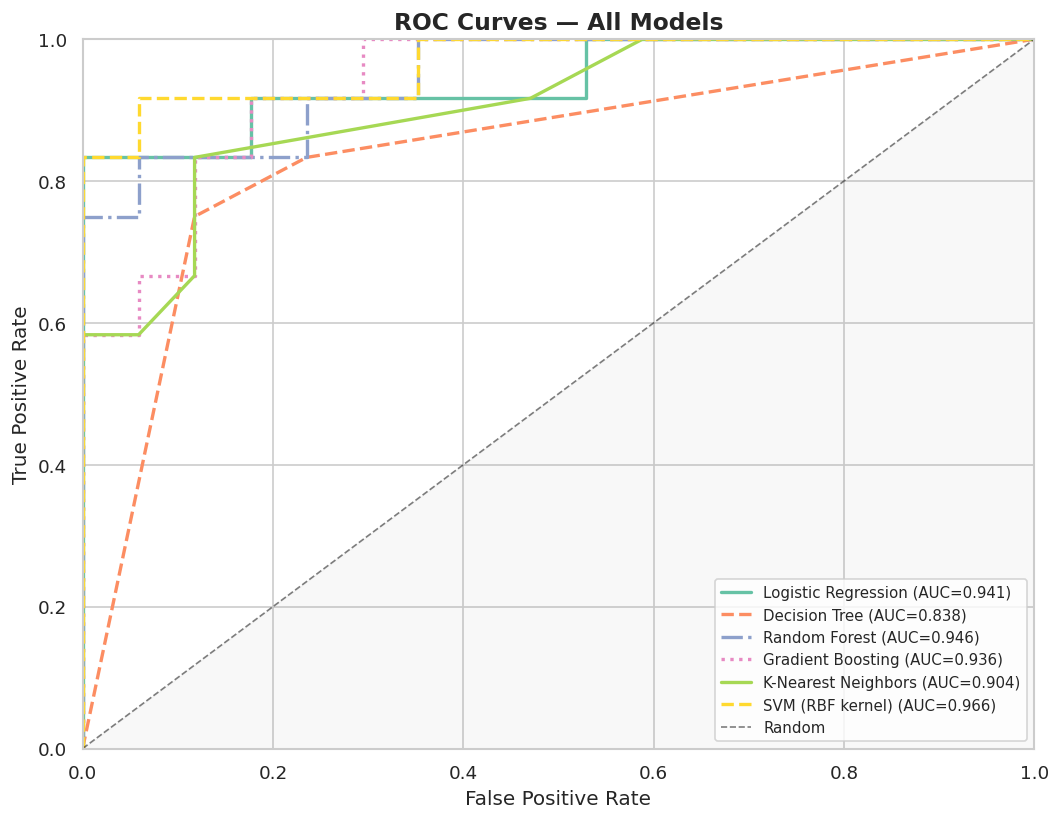

In [11]:
# ── 5b. ROC CURVES ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
line_styles = ['-', '--', '-.', ':', '-', '--']

for (name, r), ls in zip(results.items(), line_styles):
    fpr, tpr, _ = roc_curve(y_val, r['y_prob'])
    ax.plot(fpr, tpr, ls, lw=2, label=f'{name} (AUC={r["roc_auc"]:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='Random')
ax.fill_between([0,1],[0,1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('plot_06_roc_curves.png', bbox_inches='tight')
plt.show()

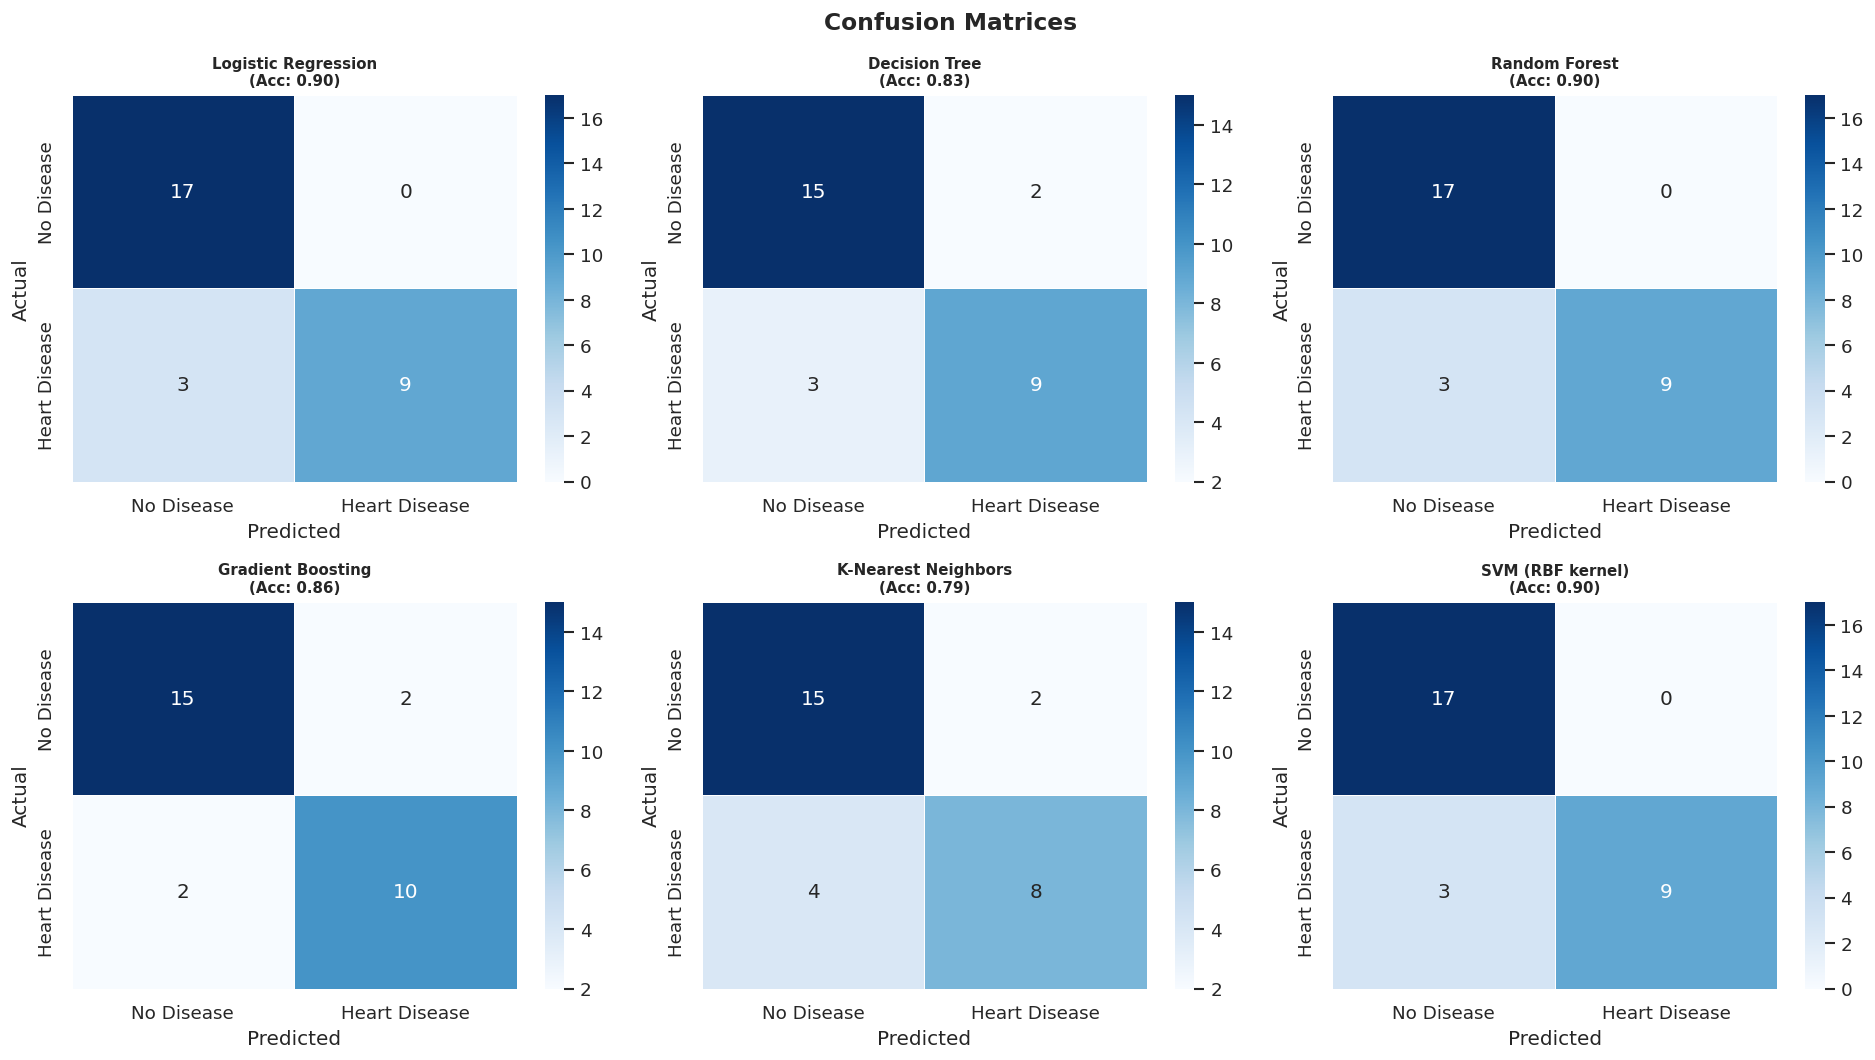

In [12]:
# ── 5c. CONFUSION MATRICES ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(y_val, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Disease', 'Heart Disease'],
                yticklabels=['No Disease', 'Heart Disease'],
                linewidths=0.5)
    axes[i].set_title(f'{name}\n(Acc: {r["accuracy"]:.2f})', fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('plot_07_confusion_matrices.png', bbox_inches='tight')
plt.show()

---
## 🏆 Step 5 — Best Model & Feature Importance

In [13]:
# ── 6. BEST MODEL: GRADIENT BOOSTING ─────────────────────────────────────────
best_name = max(results, key=lambda k: results[k]['roc_auc'])
best_result = results[best_name]
print(f'🏆 Best Model: {best_name}')
print(f'   AUC      : {best_result["roc_auc"]:.4f}')
print(f'   Accuracy : {best_result["accuracy"]:.4f}')
print(f'   F1 Score : {best_result["f1"]:.4f}')
print()
print('Classification Report:')
print(classification_report(y_val, best_result['y_pred'],
                            target_names=['No Disease', 'Heart Disease']))

🏆 Best Model: SVM (RBF kernel)
   AUC      : 0.9657
   Accuracy : 0.8966
   F1 Score : 0.8571

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.85      1.00      0.92        17
Heart Disease       1.00      0.75      0.86        12

     accuracy                           0.90        29
    macro avg       0.93      0.88      0.89        29
 weighted avg       0.91      0.90      0.89        29



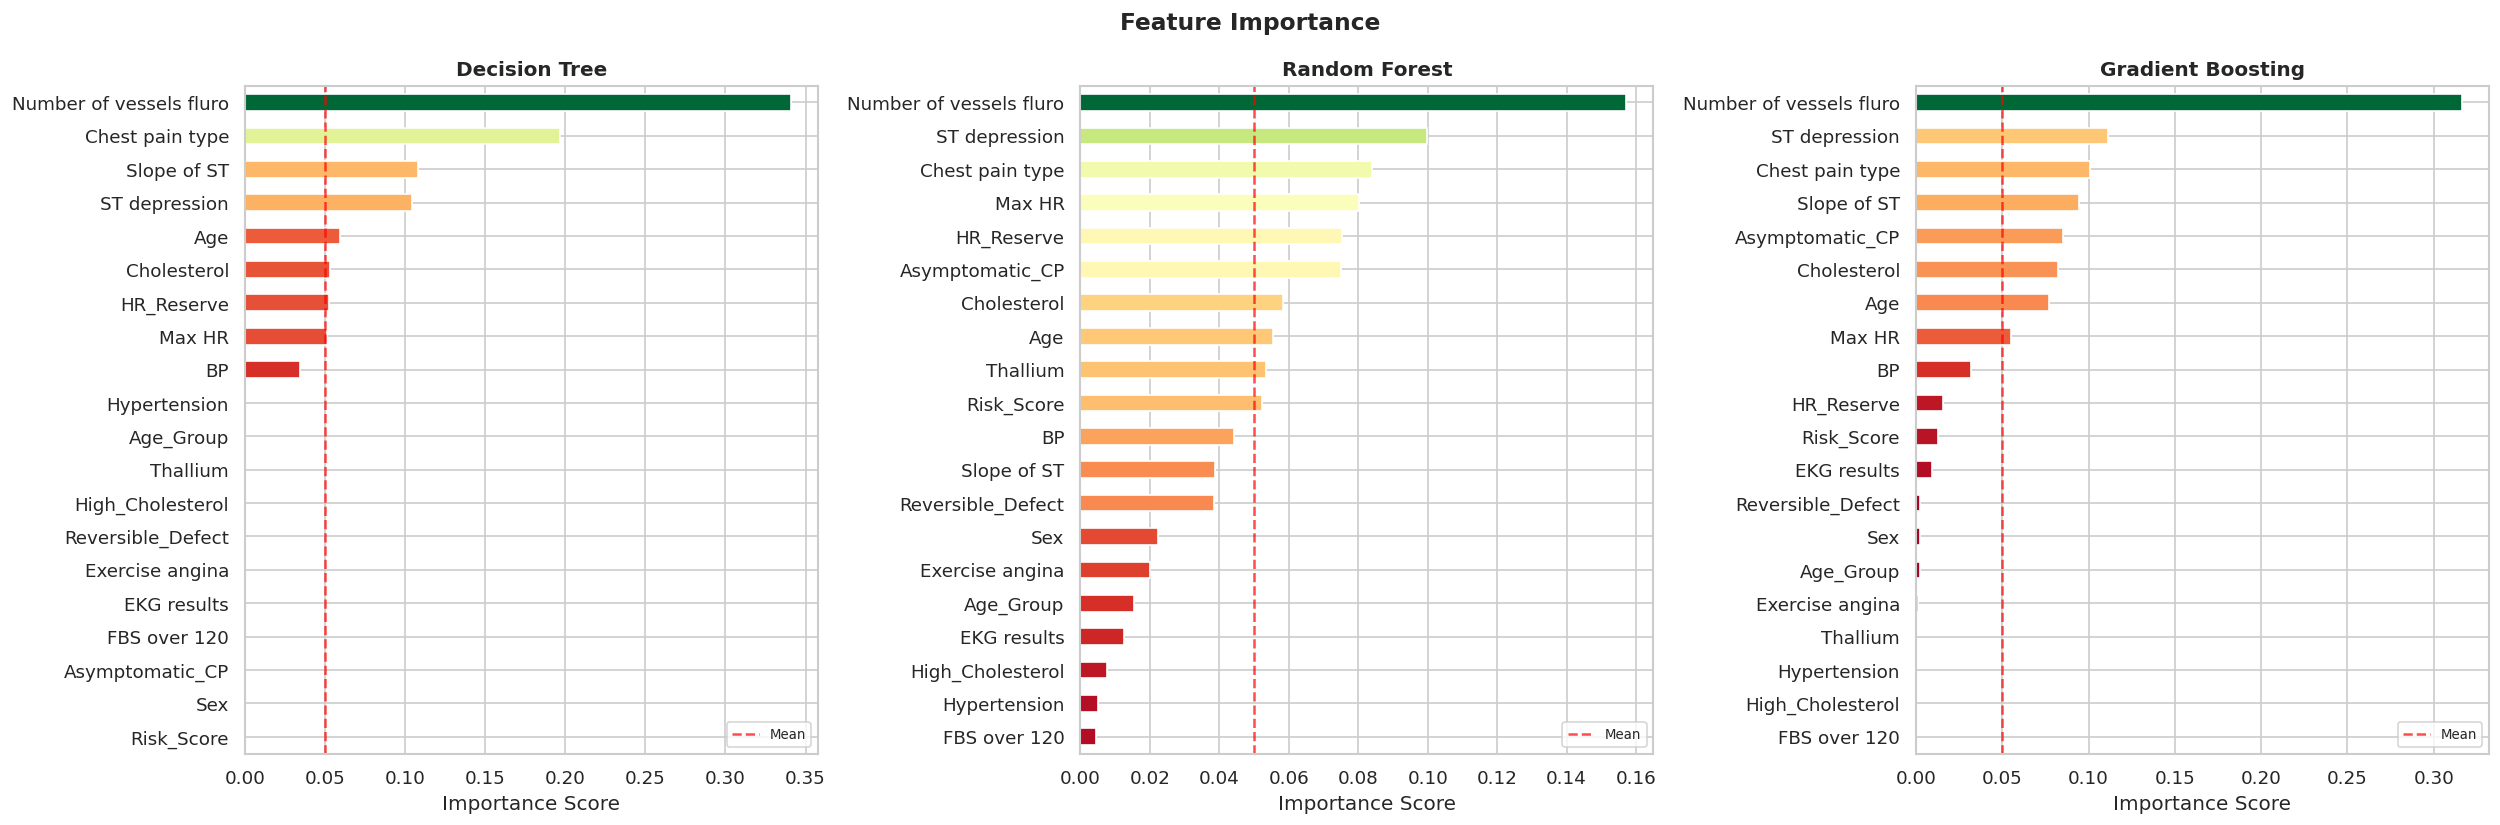

In [14]:
# ── 6b. FEATURE IMPORTANCE (Gradient Boosting & Random Forest) ───────────────
tree_models = {k: v for k, v in results.items() 
               if hasattr(v['model'], 'feature_importances_')}

fig, axes = plt.subplots(1, len(tree_models), figsize=(7*len(tree_models), 7))
if len(tree_models) == 1:
    axes = [axes]
fig.suptitle('Feature Importance', fontsize=14, fontweight='bold')

for ax, (name, r) in zip(axes, tree_models.items()):
    importances = r['model'].feature_importances_
    feat_imp = pd.Series(importances, index=FEATURE_COLS_ENGINEERED).sort_values(ascending=True)
    
    colors_imp = plt.cm.RdYlGn(feat_imp.values / feat_imp.values.max())
    feat_imp.plot(kind='barh', ax=ax, color=colors_imp)
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.axvline(feat_imp.mean(), color='red', linestyle='--', alpha=0.7, label='Mean')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('plot_08_feature_importance.png', bbox_inches='tight')
plt.show()

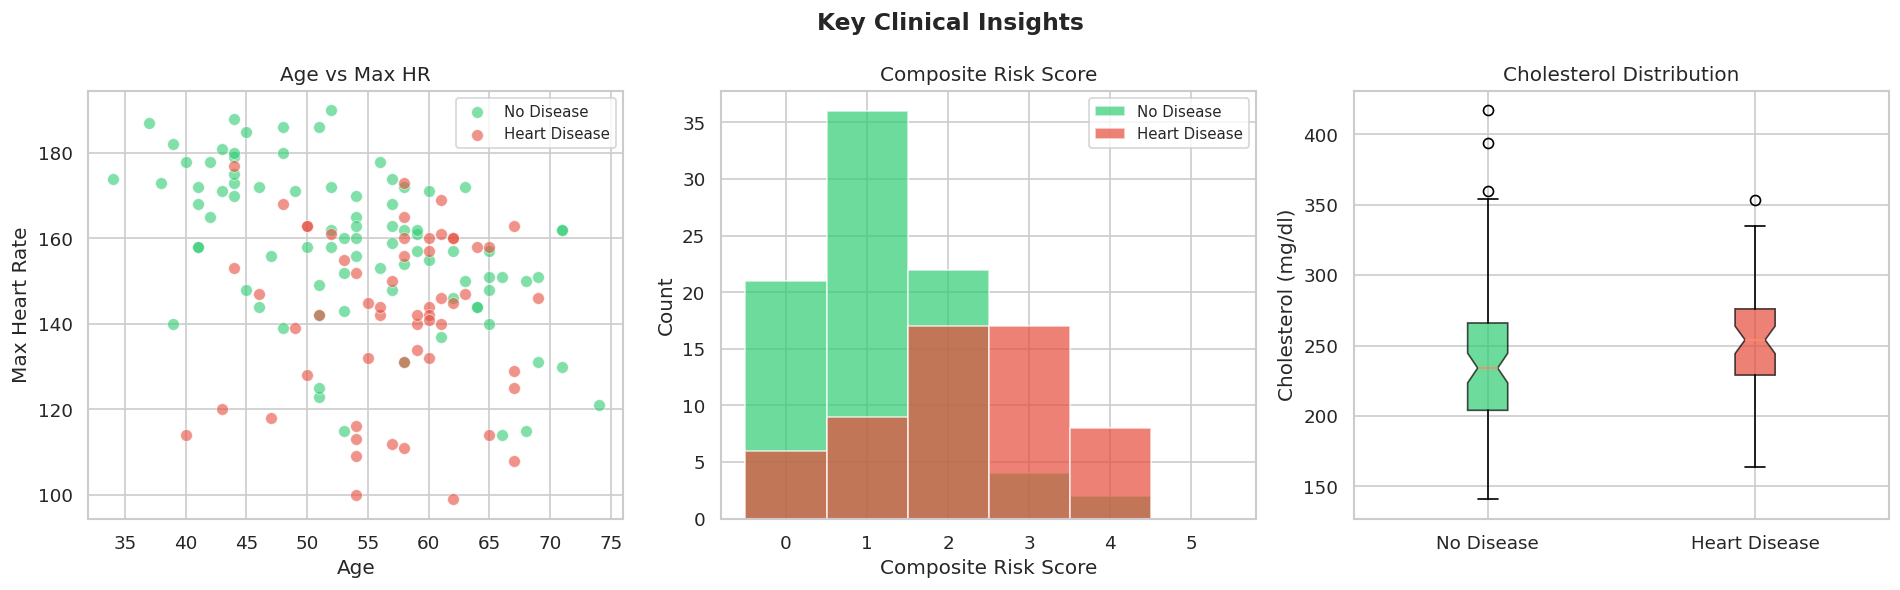

In [15]:
# ── 6c. CLINICAL INSIGHTS PLOT ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Key Clinical Insights', fontsize=14, fontweight='bold')

# 1. Age vs Max HR (colored by disease)
for cls, color, label in zip([0, 1], COLORS, ['No Disease', 'Heart Disease']):
    mask = train_df[TARGET_COL] == cls
    axes[0].scatter(train_df.loc[mask, 'Age'], train_df.loc[mask, 'Max HR'],
                    c=color, alpha=0.6, label=label, s=50, edgecolors='white', linewidth=0.5)
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Max Heart Rate')
axes[0].set_title('Age vs Max HR')
axes[0].legend(fontsize=9)

# 2. Risk Score distribution
for cls, color, label in zip([0, 1], COLORS, ['No Disease', 'Heart Disease']):
    data = train_df[train_df[TARGET_COL] == cls]['Risk_Score']
    axes[1].hist(data, bins=range(0, 7), alpha=0.7, color=color, label=label,
                 edgecolor='white', align='left')
axes[1].set_xlabel('Composite Risk Score'); axes[1].set_ylabel('Count')
axes[1].set_title('Composite Risk Score')
axes[1].legend(fontsize=9)

# 3. Box plot: Cholesterol by disease
data_0 = train_df[train_df[TARGET_COL] == 0]['Cholesterol']
data_1 = train_df[train_df[TARGET_COL] == 1]['Cholesterol']
bp = axes[2].boxplot([data_0, data_1], labels=['No Disease', 'Heart Disease'],
                      patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_ylabel('Cholesterol (mg/dl)')
axes[2].set_title('Cholesterol Distribution')

plt.tight_layout()
plt.savefig('plot_09_clinical_insights.png', bbox_inches='tight')
plt.show()

---
## 📤 Step 6 — Generate Predictions on Test Set

In [16]:
# ── 7. PREDICT ON TEST SET ────────────────────────────────────────────────────
# Retrain best model on full training data
best_model = results[best_name]['model']
best_model.fit(X_train, y_train)  # Full training set

test_preds = best_model.predict(X_test)
test_probs = best_model.predict_proba(X_test)[:, 1]

# Create submission file
submission = pd.DataFrame({
    'id'                       : test_df['id'],
    'Heart Disease'            : test_preds,
    'Heart Disease Probability': test_probs.round(4)
})

submission.to_csv('submission.csv', index=False)

print(f'✅ Predictions saved to submission.csv')
print(f'   Total predictions    : {len(submission):,}')
print(f'   Predicted No Disease : {(test_preds==0).sum():,} ({(test_preds==0).mean()*100:.1f}%)')
print(f'   Predicted Heart Dis. : {(test_preds==1).sum():,} ({(test_preds==1).mean()*100:.1f}%)')
print(f'\nFirst 10 predictions:')
print(submission.head(10).to_string(index=False))

✅ Predictions saved to submission.csv
   Total predictions    : 270,000
   Predicted No Disease : 256,641 (95.1%)
   Predicted Heart Dis. : 13,359 (4.9%)

First 10 predictions:
    id  Heart Disease  Heart Disease Probability
630000              0                     0.5382
630001              0                     0.2153
630002              0                     0.5000
630003              0                     0.2320
630004              0                     0.3927
630005              0                     0.5520
630006              0                     0.3723
630007              0                     0.4410
630008              0                     0.6310
630009              0                     0.4120


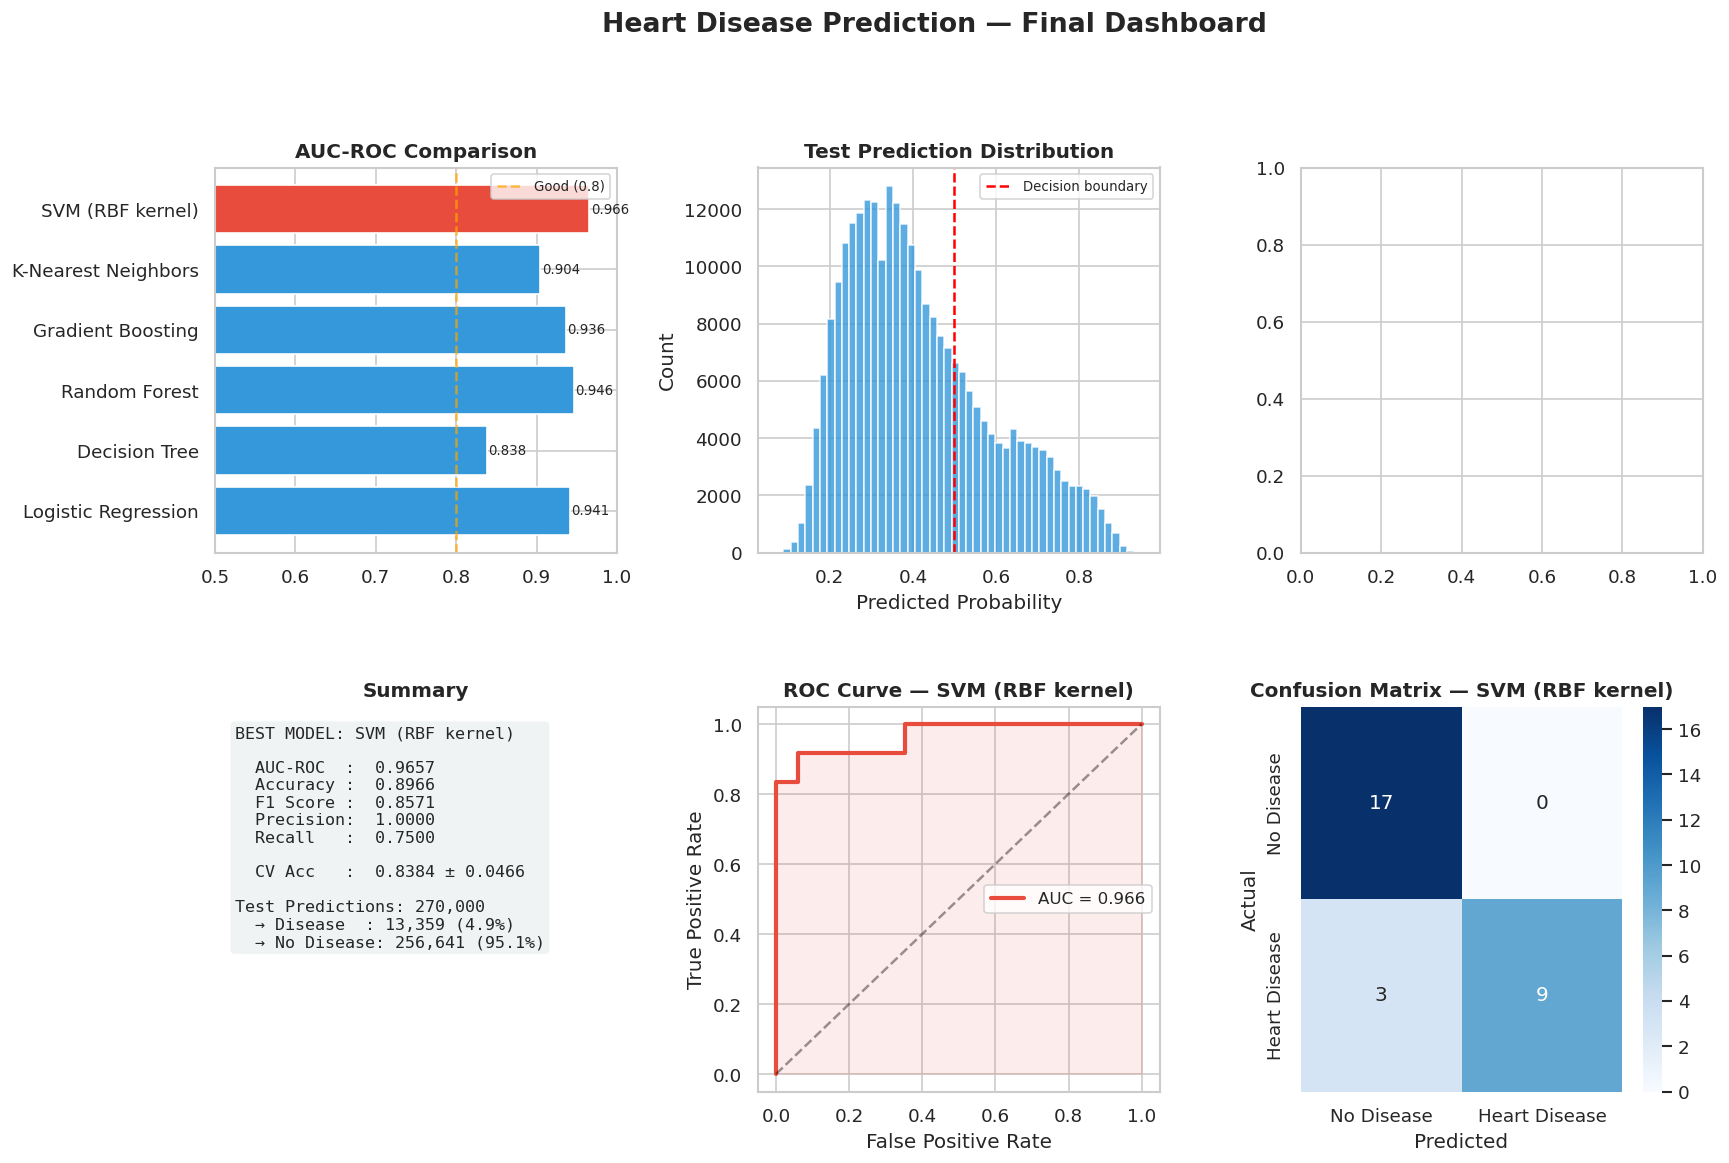


🎉 Pipeline complete! All plots and submission.csv generated.


In [17]:
# ── 8. FINAL SUMMARY DASHBOARD ───────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Heart Disease Prediction — Final Dashboard', fontsize=16, fontweight='bold', y=1.01)

gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

# AUC comparison
ax1 = fig.add_subplot(gs[0, 0])
names = list(results.keys())
aucs  = [results[n]['roc_auc'] for n in names]
cols  = ['#e74c3c' if n == best_name else '#3498db' for n in names]
bars  = ax1.barh(names, aucs, color=cols)
ax1.set_xlim(0.5, 1.0)
ax1.axvline(0.8, color='orange', linestyle='--', alpha=0.7, label='Good (0.8)')
for bar, val in zip(bars, aucs):
    ax1.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=8)
ax1.set_title('AUC-ROC Comparison', fontweight='bold')
ax1.legend(fontsize=8)

# Prediction distribution
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(test_probs, bins=50, color='#3498db', alpha=0.8, edgecolor='white')
ax2.axvline(0.5, color='red', linestyle='--', label='Decision boundary')
ax2.set_xlabel('Predicted Probability')
ax2.set_ylabel('Count')
ax2.set_title('Test Prediction Distribution', fontweight='bold')
ax2.legend(fontsize=8)

# Feature importance (best model)
ax3 = fig.add_subplot(gs[0, 2])
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=FEATURE_COLS_ENGINEERED)
    top_fi = fi.nlargest(8)
    top_fi.sort_values().plot(kind='barh', ax=ax3, color='#2ecc71')
    ax3.set_title(f'Top Features ({best_name})', fontweight='bold')

# Summary metrics text
ax4 = fig.add_subplot(gs[1, 0])
ax4.axis('off')
summary_text = (
    f'BEST MODEL: {best_name}\n\n'
    f'  AUC-ROC  :  {best_result["roc_auc"]:.4f}\n'
    f'  Accuracy :  {best_result["accuracy"]:.4f}\n'
    f'  F1 Score :  {best_result["f1"]:.4f}\n'
    f'  Precision:  {best_result["precision"]:.4f}\n'
    f'  Recall   :  {best_result["recall"]:.4f}\n\n'
    f'  CV Acc   :  {best_result["cv_mean"]:.4f} ± {best_result["cv_std"]:.4f}\n\n'
    f'Test Predictions: {len(test_preds):,}\n'
    f'  → Disease  : {(test_preds==1).sum():,} ({(test_preds==1).mean()*100:.1f}%)\n'
    f'  → No Disease: {(test_preds==0).sum():,} ({(test_preds==0).mean()*100:.1f}%)'
)
ax4.text(0.05, 0.95, summary_text, transform=ax4.transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#ecf0f1', alpha=0.8))
ax4.set_title('Summary', fontweight='bold')

# ROC curve of best model
ax5 = fig.add_subplot(gs[1, 1])
fpr, tpr, _ = roc_curve(y_val, best_result['y_prob'])
ax5.plot(fpr, tpr, color='#e74c3c', lw=2.5, label=f'AUC = {best_result["roc_auc"]:.3f}')
ax5.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
ax5.plot([0,1],[0,1],'k--',alpha=0.4)
ax5.set_xlabel('False Positive Rate')
ax5.set_ylabel('True Positive Rate')
ax5.set_title(f'ROC Curve — {best_name}', fontweight='bold')
ax5.legend(fontsize=10)

# Confusion matrix of best
ax6 = fig.add_subplot(gs[1, 2])
cm = confusion_matrix(y_val, best_result['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax6,
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'])
ax6.set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
ax6.set_xlabel('Predicted'); ax6.set_ylabel('Actual')

plt.savefig('plot_10_final_dashboard.png', bbox_inches='tight', dpi=130)
plt.show()
print('\n🎉 Pipeline complete! All plots and submission.csv generated.')